✅ Loaded 2484 resumes
✅ TF-IDF fitted!

🔑 Top 10 keywords per category:

📂 HR: employee | human | human resources | benefits | management | recruitment | resources | employees | payroll | compensation
📂 DESIGNER: design | designer | graphic | city | state | city state | interior | company | art | graphic designer
📂 INFORMATION-TECHNOLOGY: network | technology | information technology | systems | information | server | security | support | software | hardware
📂 TEACHER: teacher | students | student | classroom | children | learning | teaching | state | lesson | city
📂 ADVOCATE: customer | advocate | state | city | city state | care | service | patient | company | name city
📂 BUSINESS-DEVELOPMENT: sales | business | business development | marketing | development | company | state | new | customer | city
📂 HEALTHCARE: healthcare | patient | care | medical | patients | health | state | management | city | city state
📂 FITNESS: fitness | exercise | sales | state | city | customer | city sta

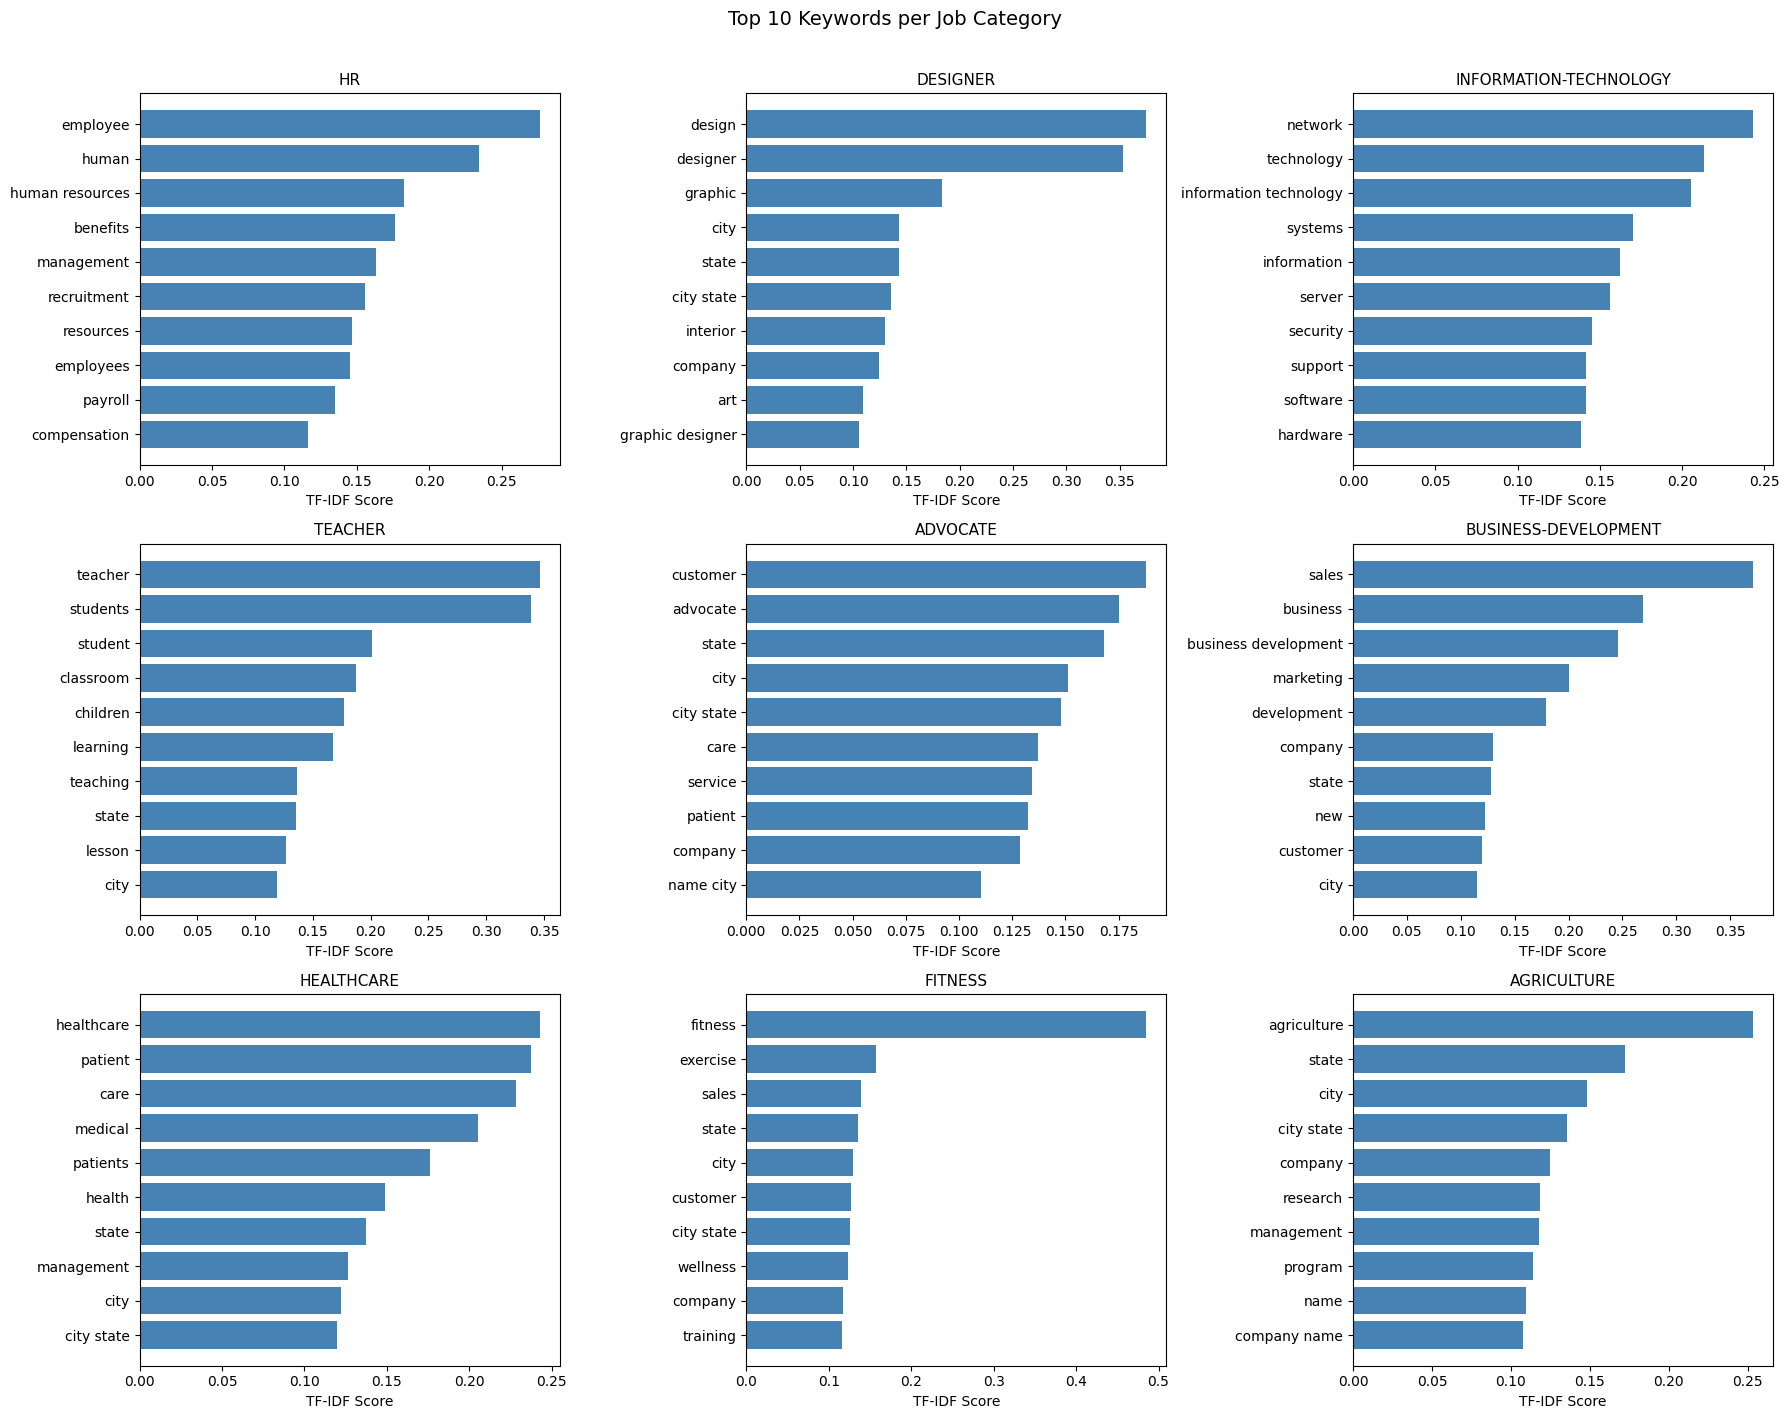

✅ Plot saved → results/plots/resume_keywords_per_category.png


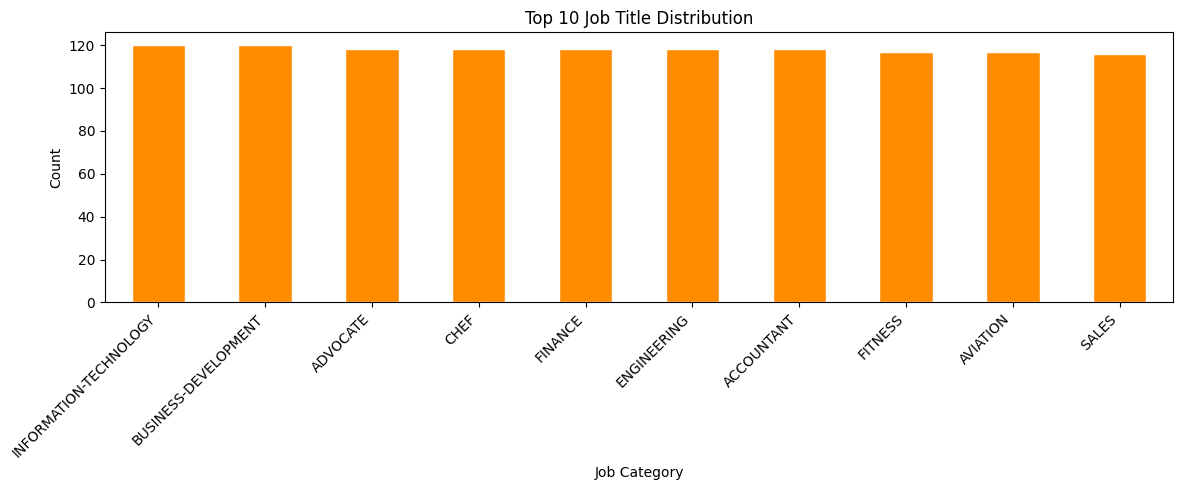

✅ Plot saved → results/plots/job_title_distribution.png


In [3]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import os

os.makedirs("../results/plots", exist_ok=True)

# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/resume_dataset.csv")
print(f"✅ Loaded {len(df)} resumes")

# ── Cell 3: Fit TF-IDF ────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf.fit(df['clean_text'].dropna())
feature_names = tfidf.get_feature_names_out()
print("✅ TF-IDF fitted!")

# ── Cell 4: Top keywords per category ─────────────────────────────────────────
def get_top_keywords(texts, n=10):
    combined = ' '.join(texts)
    vec = tfidf.transform([combined]).toarray()[0]
    top_idx = vec.argsort()[::-1][:n]
    return [(feature_names[i], round(vec[i], 4)) for i in top_idx if vec[i] > 0]

print("\n🔑 Top 10 keywords per category:\n")
all_keywords = {}
for cat in df['Category'].unique():
    texts = df[df['Category'] == cat]['clean_text'].dropna().tolist()
    kws = get_top_keywords(texts)
    all_keywords[cat] = kws
    print(f"📂 {cat}: {' | '.join([w for w,_ in kws])}")

# ── Cell 5: Plot top keywords per category ────────────────────────────────────
categories = list(all_keywords.keys())[:9]   # plot up to 9 categories
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, cat in enumerate(categories):
    words, scores = zip(*all_keywords[cat])
    axes[i].barh(words[::-1], scores[::-1], color='steelblue')
    axes[i].set_title(f'{cat}', fontsize=11)
    axes[i].set_xlabel('TF-IDF Score')

plt.suptitle('Top 10 Keywords per Job Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../results/plots/resume_keywords_per_category.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved → results/plots/resume_keywords_per_category.png")

# ── Cell 6: Job title distribution ────────────────────────────────────────────
top_cats = df['Category'].value_counts().head(10)
plt.figure(figsize=(12, 5))
top_cats.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 10 Job Title Distribution')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../results/plots/job_title_distribution.png", dpi=150)
plt.show()
print("✅ Plot saved → results/plots/job_title_distribution.png")